In [ ]:
!nvidia-smi

Mon Mar 21 02:44:31 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla K80           Off  | 00000000:00:04.0 Off |                    0 |
| N/A   34C    P8    28W / 149W |      0MiB / 11441MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

# Mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Mount google drive by excuting the above cell

# Import library

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
keras.__version__

'2.8.0'

# Dataset loading

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,    # 圖片像素值為0-255，此處都乘以1/255，調整到0-1之間
    ) 
train_generator = train_datagen.flow_from_directory( # 從文件夾中產生數據流
    directory="/content/drive/Shareddrives/110-2 深度學習於生醫資料分析/Datasets/MURA/train", # 訓練集圖片的文件夾
    target_size=(224, 224), # 調整後每張圖片的大小
    class_mode="sparse",
    batch_size=32,
    )


valid_datagen = ImageDataGenerator(
    rescale=1./255,
    ) 
valid_generator = valid_datagen.flow_from_directory(
    directory="/content/drive/Shareddrives/110-2 深度學習於生醫資料分析/Datasets/MURA/valid",
    target_size=(224, 224),
    class_mode="sparse",
    batch_size=32,
    shuffle=False
    )


test_datagen = ImageDataGenerator(
    rescale=1./255,
    ) 
test_generator = test_datagen.flow_from_directory(
    directory="/content/drive/Shareddrives/110-2 深度學習於生醫資料分析/Datasets/MURA/test",
    target_size=(224, 224),
    class_mode="sparse",
    batch_size=32,
    shuffle=False
    )

Found 9032 images belonging to 3 classes.
Found 1289 images belonging to 3 classes.
Found 2580 images belonging to 3 classes.


> 以上 rescale 的技巧稱為資料正規化(normalization)，此操作是為了讓輸入資料和 weights 有相似的 range，以避免需花費額化的時間成本在調整超參數上(例如 learning rate)。



In [ ]:
batch_img, batch_label = train_generator[0]

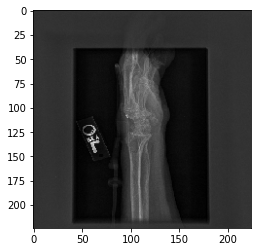

2.0
WRIST_negative


In [ ]:
import matplotlib.pyplot as plt

i = 0

plt.imshow(batch_img[i])
plt.show()

print(batch_label[i])
class_indices_reverse = {v:k for k,v in train_generator.class_indices.items()}
print(class_indices_reverse[int(batch_label[i])])

# Model building

In [ ]:
from tensorflow.keras import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers.experimental import preprocessing

In [ ]:
def VGG16(input_shape=(224, 224, 3), num_classes=3):
    img_input = Input(shape=input_shape)

    #block 1
    x = Conv2D(filters=64, kernel_size=(3, 3),
        activation='relu', padding='same')(img_input)
    x = Conv2D(filters=64, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 2
    x = Conv2D(filters=128, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=128, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 3
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=256, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 4
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #block 5
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = Conv2D(filters=512, kernel_size=(3, 3),
        activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)

    #flatten
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    x = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=img_input, outputs=x)

In [ ]:
model_path = "/content/drive/MyDrive/VGG16_224_MURA.h5"

if os.path.exists(model_path):
    print("Found model, it will keep training!")
    model = load_model(model_path)
else:
    model = VGG16()

In [ ]:
model = VGG16()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 64)      1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 64)     0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 112, 112, 128)     73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 112, 112, 128)     147584    
                                                             

# Compile the model

In [ ]:
from tensorflow.keras.optimizers import Adam


model.compile(
    loss='sparse_categorical_crossentropy', #多元分類問題(整數標籤)，故使用此損失函數
    metrics=['accuracy'],
    optimizer=Adam(learning_rate=0.0001)  #lr:學習率 = 0.0001
    #optimizer='adam' #用這種方法也行，但只能使用預設參數
    )

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint


checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_accuracy',
    verbose=1, save_best_only=True, #只存取準確率最高的模型和權重
    mode='max')

callbacks_list = [checkpoint]

# Start training

In [ ]:
train_history = model.fit(
    train_generator,
    epochs=10,
    verbose=1,
    callbacks=callbacks_list,
    validation_data=valid_generator,
    use_multiprocessing=True,
    workers=32
    )

Epoch 1/10
283/283 [==============================] - ETA: 0s - loss: 0.5751 - accuracy: 0.7606
Epoch 1: val_accuracy improved from -inf to 0.85415, saving model to /content/drive/MyDrive/VGG16_224_MURA.h5


Process Keras_worker_ForkPoolWorker-43:
Process Keras_worker_ForkPoolWorker-47:
Process Keras_worker_ForkPoolWorker-57:
Process Keras_worker_ForkPoolWorker-58:
Process Keras_worker_ForkPoolWorker-34:
Process Keras_worker_ForkPoolWorker-60:
Process Keras_worker_ForkPoolWorker-35:
Process Keras_worker_ForkPoolWorker-48:
Process Keras_worker_ForkPoolWorker-33:
Process Keras_worker_ForkPoolWorker-64:
Process Keras_worker_ForkPoolWorker-63:
Process Keras_worker_ForkPoolWorker-52:
Process Keras_worker_ForkPoolWorker-62:
Process Keras_worker_ForkPoolWorker-51:
Process Keras_worker_ForkPoolWorker-41:
Process Keras_worker_ForkPoolWorker-55:
Process Keras_worker_ForkPoolWorker-50:
Process Keras_worker_ForkPoolWorker-38:
Process Keras_worker_ForkPoolWorker-44:
Process Keras_worker_ForkPoolWorker-45:
Process Keras_worker_ForkPoolWorker-53:
Process Keras_worker_ForkPoolWorker-40:
Process Keras_worker_ForkPoolWorker-39:
Process Keras_worker_ForkPoolWorker-54:
Process Keras_worker_ForkPoolWorker-49:


KeyboardInterrupt: ignored

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False)

94781440/94765736 [==============================] - 1s 0us/step


In [ ]:
base_model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, None, None,   0           ['input_2[0][0]']                
                                3)                                                                
                                                                                                  
 conv1_conv (Conv2D)            (None, None, None,   9472        ['conv1_pad[0][0]']              
                                64)                                                        

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, None, None,   0           ['input_2[0][0]']                
                                3)                                                                
                                                                                                  
 conv1_conv (Conv2D)            (None, None, None,   9472        ['conv1_pad[0][0]']              
                                64)                                                         

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input
import numpy as np

base_model = VGG19(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('block4_pool').output)

img_path = '/content/elephant.jpg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

block4_pool_features = model.predict(x)

574726144/574710816 [==============================] - 5s 0us/step


FileNotFoundError: ignored

# Save model

In [ ]:
# model.save("/content/drive/MyDrive/YM/HW_VGG16/weights/VGG16_224_MURA_end.h5")

# Draw the training processing plot

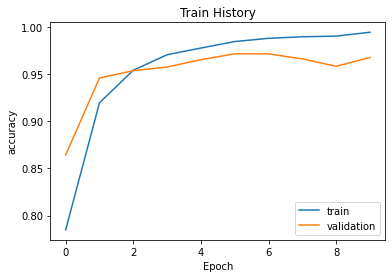

In [ ]:
import matplotlib.pyplot as plt


plt.plot(train_history.history['accuracy'])
plt.plot(train_history.history['val_accuracy'])
plt.title('Train History')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.savefig('Train_History_accuracy.png')

plt.show()

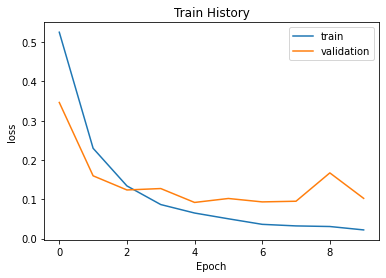

In [ ]:
plt.plot(train_history.history['loss'])
plt.plot(train_history.history['val_loss'])
plt.title('Train History')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.savefig('Train_History_loss.png')

plt.show()

In [ ]:
scores = model.evaluate(
    train_generator,
    use_multiprocessing=True,
    workers=20
    )
print("train_acc:", scores[1])

283/283 [==============================] - 46s 151ms/step - loss: 0.0151 - accuracy: 0.9950
train_acc: 0.9950177073478699


In [ ]:
vali_scores = model.evaluate(
    valid_generator,
    use_multiprocessing=True,
    workers=20
    )
print("valid_acc:", vali_scores[1])

41/41 [==============================] - 10s 170ms/step - loss: 0.1024 - accuracy: 0.9674
valid_acc: 0.9674165844917297


# Testing

In [ ]:
test_scores = model.evaluate(
    test_generator,
    use_multiprocessing=True,
    workers=20
    )
print("test_acc:", test_scores[1])

In [ ]:
pred = model.predict(
    test_generator,
    use_multiprocessing=True,
    workers=20
    )
predicted_class_indices = np.argmax(pred, axis=1)

In [ ]:
batch_test_img, batch_test_label = test_generator[0]

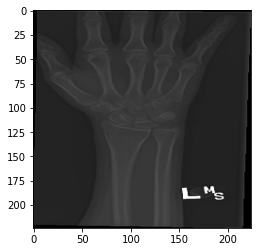

prediction: WRIST_negative


In [ ]:
i = 0

plt.imshow(batch_test_img[i])
plt.show()

print(class_indices_reverse[int(batch_test_label[i])])
print(class_indices_reverse[predicted_class_indices])

# Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix


CNN_confusion_matrix = confusion_matrix(test_label, predicted_class_indices)
print(CNN_confusion_matrix)

[[ 554   14   17]
 [   6  830    6]
 [  15   11 1127]]
